In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import RFE

from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_percentage_error

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
import csv
import time
import glob

# Supress warnings
import warnings
warnings.filterwarnings("ignore")


# Datasize in KB
data_size_kb = {'4mb': 4096, '16mb': 16384, '64mb': 65536,
            '256mb': 262144, '512mb': 524288, '1gb': 1048576,
            '5gb': 5242880, '50gb': 52428800, '100gb': 104857600,
            '300gb': 314572800,}

# Key Parameters
IO_FEATURES = ['operation', 'randomOffset', 'transferSize', 
            'aggregateFilesize', 'numTasks', 'totalTime', 
            'numNodes', 'tasksPerNode', "storageType"]

IO_TARGET = ['bwMiB', 'storageType']


In [2]:
def encode_df(df):
  le = preprocessing.LabelEncoder()
  for col in df.columns:
      if pd.api.types.is_object_dtype(df[col]):
          df.fillna('', inplace=True)
          df[col] = le.fit_transform(df[col].astype(str))
      elif pd.api.types.is_string_dtype(df[col]):
          df.fillna('', inplace=True)
          df[col] = le.fit_transform(df[col].astype(str))
      elif pd.api.types.is_datetime64_any_dtype(df[col]):
          df.fillna('', inplace=True)
          df[col] = le.fit_transform(df[col].astype(str))
      else:
          df.fillna(0, inplace=True)

from sklearn.metrics import davies_bouldin_score
from sklearn.cluster import KMeans

def k_means(t, df, features):
    models = {}
    inertias = []
    db_scores = []
    k_values = [2, 4, 6, 8, 10, 12]
    
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=42)
        labels = model.fit_predict(df[features])
        inertia = model.inertia_
        db_score = davies_bouldin_score(df[features], labels)
        
        models[k] = {
            'model': model,
            'labels': labels,
            'db_score': db_score,
            'inertia': inertia
        }
        
        inertias.append(inertia)
        db_scores.append(db_score)
        print(f"k={k}: DB_SCORE[{db_score}] INERTIA[{inertia}]")
    
    # Plot inertia to determine the elbow point
    plt.figure(figsize=(10, 8))
    plt.plot(k_values, inertias, '-o')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method For Optimal k')
    plt.show()
    
    # Initialize best_model with the first model
    best_model = models[k_values[0]]
    
    for k in k_values:
        if models[k]['db_score'] < best_model['db_score']:
            best_model = models[k]
    print(f"[{t}] best_model = {best_model}\n")

    return best_model


import umap.umap_ as umap
import umap.plot as umap_plt
# pip install pandas matplotlib datashader bokeh holoviews scikit-image colorcet

def visualize(df, features, labels, path=None): #self
  print("FITTING")
  #features is the 10 or so features you get from RF
  mapper = umap.UMAP().fit(df[features])
  print("DRAWING")
  #labels is the cluster a particular data point belongs to
  print(labels)
  p = umap_plt.points(mapper, labels=labels, color_key_cmap='tab10')
  umap_plt.show(p)



In [3]:
# Read dataframe from master_ior_df.csv
master_ior_df_file = './master_ior_df.csv'
ior_df = pd.read_csv(master_ior_df_file)

# Read dataframe from seq_1000_1n_ssd.csv
seq_wf_df_file = './seq_1000_1n_ssd.csv'
wf_df = pd.read_csv(seq_wf_df_file)



k=2: DB_SCORE[0.11453099669154522] INERTIA[3.770580002656722e+24]
k=4: DB_SCORE[0.05175401108284253] INERTIA[3.2224670771727e+22]
k=6: DB_SCORE[0.1717630361490005] INERTIA[8.526657701583289e+21]
k=8: DB_SCORE[0.0745799112455713] INERTIA[1.512564178296047e+21]
k=10: DB_SCORE[0.15521693953285318] INERTIA[5.4494048566392553e+20]
k=12: DB_SCORE[0.20796590988290733] INERTIA[2.3178333836170586e+20]


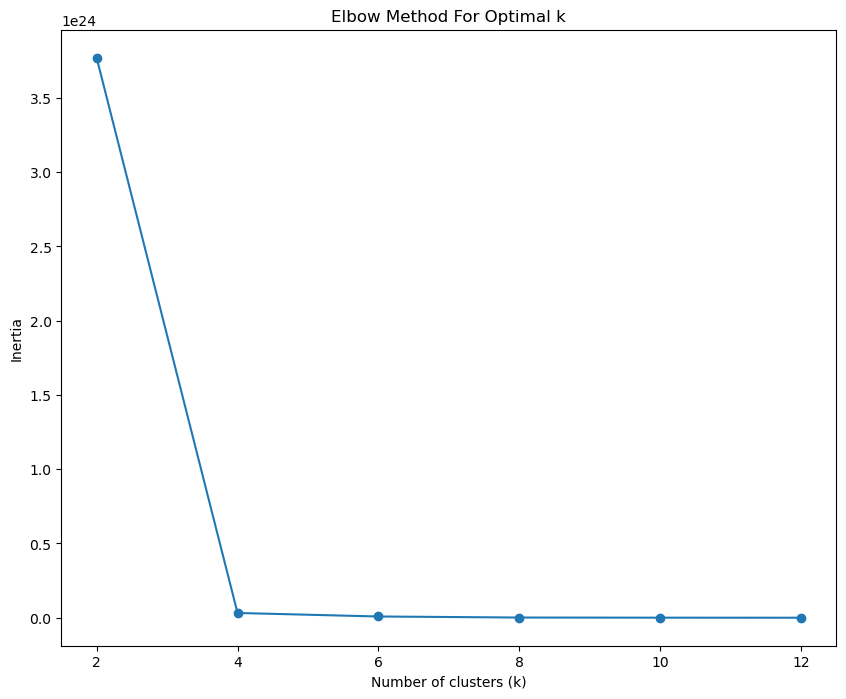

[bwMiB] best_model = {'model': KMeans(n_clusters=4, random_state=42), 'labels': array([2, 2, 2, ..., 0, 2, 2], dtype=int32), 'db_score': 0.05175401108284253, 'inertia': 3.2224670771727e+22}

FITTING
DRAWING
[2 2 2 ... 0 2 2]


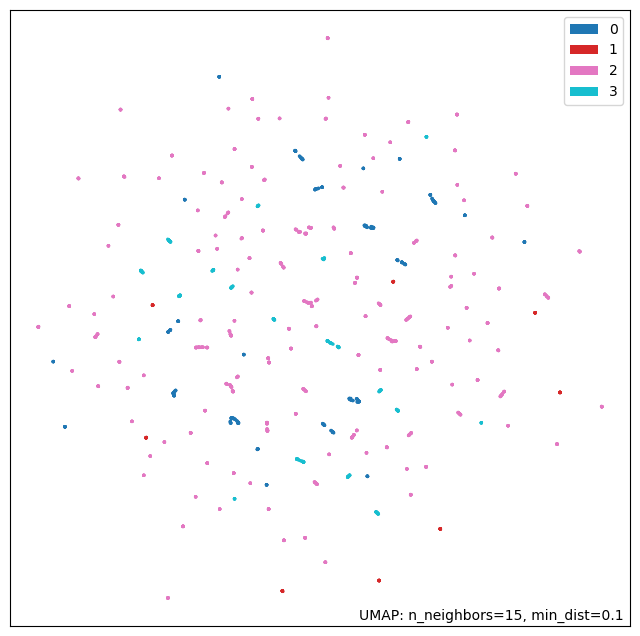

In [4]:

df = ior_df
features = IO_FEATURES
for t in IO_TARGET:
    best_model = k_means(t,df,features)
    visualize(df, features, best_model['labels'])

In [5]:
import copy
from sklearn.decomposition import PCA

def result(y_col, max_features,max_depth,n_estimators,
                        x_train,y_train):

  rfr=RandomForestRegressor(random_state=42, 
                            n_estimators=n_estimators,
                            max_features=max_features,
                            max_depth=max_depth)
  ## Feature Selector
  #Run recursive feature elimination
  selector = RFE(rfr, n_features_to_select=max_features)
  selector.fit(x_train, y_train)
  r2_score = selector.score(x_train, y_train)

  return {"variable":y_col,
          "depth":max_depth,
          "nfeatures":max_features,
          "model_r2": r2_score}

def find_model_features(max_features,max_depth,n_estimators,
                        X,y,X_cols,y_col):
  
  rfr=RandomForestRegressor(random_state=42, 
                            n_estimators=n_estimators,
                            max_features=max_features-1,
                            max_depth=max_depth)
  
  # x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  print(f"max features = {max_features}")
  print(f"X shape {X.shape} ; y shape {y.shape}")

  ## Feature Selector
  #Run recursive feature elimination
  selector = RFECV(rfr, step=1, cv=5, min_features_to_select=5)
  # selector = RFE(rfr, n_features_to_select=max_features)
  selector.fit(X, y)
  rfecv_score = selector.score(X, y)
  print(f"R^2 Score for Random Forest on [{y_col}] with {max_features} features: {rfecv_score}")

  rfecv_nfeatures = selector.n_features_

  #Get the features that were selected and the estimator trained on these features
  X_cols_subset = list(np.array(X_cols)[selector.support_])
  # sort features and importance list
  regressor = selector.estimator_
  subset_imp = regressor.feature_importances_.tolist()
  sorted_pairs = zip(*sorted(zip(subset_imp,X_cols_subset),reverse=True))
  subset_imp, X_cols_subset = [ list(pair) for pair in  sorted_pairs]
  subset_imp = [round(num, 4) for num in subset_imp]
  # X_cols_subset = selector.get_feature_names_out(list(X_cols.keys()))

  return {"variable":y_col,
          "depth":max_depth,
          "rfecv_nfeatures":rfecv_nfeatures,
          "features":X_cols_subset[0:rfecv_nfeatures],
          "importance": subset_imp,
          "rfecv_score": rfecv_score}

#reference: https://www.kaggle.com/code/sociopath00/random-forest-using-gridsearchcv/notebook
def rf_train(df,X_cols,y_col,n_features=10,CV=5,pca_n=0):
  X = df[X_cols]
  y = df[y_col] #df.pop(y_col)


  max_x = len(X_cols)

  if pca_n > 0:
    pca = PCA(n_components=pca_n)
    x_train = pca.fit_transform(X)
    x_test = pca.transform(y)
    max_x = pca_n
  

  rfr = RandomForestRegressor(random_state=0, n_jobs=12)

  #Find the best RandomForest Depth and Number of Selected Features
  forest_params = [{'max_depth': list([10,20,30]),
                    'max_features': list([int(max_x)]),
                    'n_estimators': list([100, 200])}]
                  # list(range(1,len(X_cols))). # list([len(X_cols)-1]

  gscv = GridSearchCV(estimator=rfr, param_grid=forest_params, 
                      cv= CV) #, return_train_score=True, refit = True

  gscv.fit(X, y)
  
  # print(f"CV result: {gscv.cv_results_}")
  print(f"Best params: {gscv.best_params_}")
  cvscore = gscv.best_score_
  print(f"CV Score for GridSearchCV on [{y_col}]: {cvscore}")
  # best_score_ (float): Mean cross-validated score of the best_estimator
  # score is the estimator's score, which is R^2 by default

  max_features = gscv.best_params_['max_features']
  max_depth = gscv.best_params_['max_depth']
  n_estimators = gscv.best_params_['n_estimators']

  result_dict = {}
  print(f"max_features={max_features}, max_depth={max_depth}, n_estimators={n_estimators}")
  # find best model score

  if pca_n > 0:

    for n in range(1,pca_n + 1):
      result_dict[n] = result(y_col, max_features,max_depth,n_estimators,
                                      X,y)
  else:

    if n_features < max_features:
      max_features = n_features
    
    # for n in range(5,max_features + 1):
    n = max_features
    result_dict[n] = find_model_features(max_features,max_depth,
                                          n_estimators,
                                          X,
                                          y,
                                          X_cols,
                                          y_col)
  
    result_dict[n]["cv_score"] = cvscore #round(cvscore,4)
    result_dict[n]["gscv_nfeatures"] = max_x
  
  return result_dict

def pca_features(df, targets, features):
    cv = 5

    pca_dict = {}

    for pca_n in list([3,4,5,6,7,8,9,10]):
        print(f"--------------- PCA_N[{pca_n}] ---------------")

        results = []

        for t in targets:
            
            curr_cols = copy.deepcopy(features)
            curr_cols.append(t)
            #print(curr_cols)

            df_train = df[curr_cols]
            df_train = df_train[df_train[t] != ''] # remve rows without target data

            print(f"[{t}] dataset has {df_train.shape[0]} entries")

            encode_df(df_train)

            trial = rf_train(df_train,features,t,cv,pca_n)

            results.append(trial)
            print()
        
        pca_dict[pca_n] = results
    
    return pca_dict

pca_results = pca_features(ior_df, IO_TARGET, IO_FEATURES)



# for k,v in pca_results.items():
#     print(f"PCA_N[{k}]")
#     for r in v:
#         for k2,v2 in r.items():
#             print(f"  {k2}: {v2}")
#         print()


--------------- PCA_N[3] ---------------
[bwMiB] dataset has 2604 entries


Best params: {'max_depth': 30, 'max_features': 9, 'n_estimators': 100}
CV Score for GridSearchCV on [bwMiB]: 0.7402446183824999
max_features=9, max_depth=30, n_estimators=100
max features = 5
X shape (2604, 9) ; y shape (2604,)
R^2 Score for Random Forest on [bwMiB] with 5 features: 0.9995126075953094

--------------- PCA_N[4] ---------------
[bwMiB] dataset has 2604 entries
Best params: {'max_depth': 30, 'max_features': 9, 'n_estimators': 200}
CV Score for GridSearchCV on [bwMiB]: 0.8221670239245343
max_features=9, max_depth=30, n_estimators=200
max features = 5
X shape (2604, 9) ; y shape (2604,)
R^2 Score for Random Forest on [bwMiB] with 5 features: 0.9995396329191105

--------------- PCA_N[5] ---------------
[bwMiB] dataset has 2604 entries
Best params: {'max_depth': 20, 'max_features': 9, 'n_estimators': 100}
CV Score for GridSearchCV on [bwMiB]: 0.851164579558118
max_features=9, max_depth=20, n_estimators=100
max features = 5
X shape (2604, 9) ; y shape (2604,)
R^2 Score for Ran

In [6]:
# Save pca_results to a txt file
with open('pca_results.txt', 'w') as file:
    for k,v in pca_results.items():
        print(f"PCA_N[{k}]")
        for r in v:
            for k2,v2 in r.items():
                file.write(f"{k2}: {v2}\n")

    

PCA_N[3]
PCA_N[4]
PCA_N[5]
PCA_N[6]
PCA_N[7]
PCA_N[8]
PCA_N[9]
PCA_N[10]


In [8]:
# from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

for iot in IO_TARGET:

    # Separate features and target
    X_train = ior_df.drop(columns=[iot])
    y_train = ior_df[iot]
    X_test = wf_df.drop(columns=[iot])
    y_test = wf_df[iot]

    # Standardize the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train the model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # Predict on the test data
    y_pred = model.predict(X_test_scaled)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Results for {iot}----------------")

    print(f"Mean Squared Error: {mse}")
    print(f"R^2 Score: {r2}")

    # Display actual vs predicted values
    results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    print(results)

Results for bwMiB----------------
Mean Squared Error: 8.314245242504715e+18
R^2 Score: -1.734701018975068
          Actual     Predicted
0   4.425645e+08 -10555.264735
1   4.376283e+09   8687.570463
2   5.636144e+08 -10535.803449
3   4.097455e+09   8705.077573
4   4.888544e+08 -10516.342911
5   4.368129e+09   8726.438337
6   4.935394e+08 -10496.882217
7   4.779690e+09   8748.375716
8   4.431237e+08 -10477.421644
9   4.372958e+09   8765.391565
10  5.590443e+08 -10457.960096
11  4.555274e+09   8786.002192
12  9.554266e+08 -10438.561918
13  4.167269e+09   8802.894921
14  8.018078e+08 -10419.113728
15  4.534648e+09   8824.798206
16  6.762151e+08 -10399.635501
17  3.692668e+09   8837.941483
18  6.731192e+08 -10380.117223
19  2.728509e+09   8845.374142
20  4.474046e+08 -10360.657673
21  2.952546e+09   8868.334090
22  9.442783e+08 -10341.257959
23  3.002026e+09   8888.490829
